# Wybrane Zagadnienia Sztucznej Inteligencji — Zestaw Zaliczeniowy

**WSEI Kraków · semestr letni 2026 · prowadzący: Michał Madejski**

---

## Filozofia tego zestawu

Sześć laboratoriów przeprowadziło Cię od **najprostszego klasyfikatora liniowego** (perceptron) do **sieci pamiętających kontekst** (LSTM). Ten zestaw zaliczeniowy zmusza Cię do **świadomego użycia tych architektur** — każdą na świeżym datasecie z Hugging Face, z porównaniem przed/po.

**Datasety z HF Hub:**
- `sklearn iris` (lokalny w sklearn — używamy do wprowadzenia perceptronu)
- [`zalando-datasets/fashion_mnist`](https://huggingface.co/datasets/zalando-datasets/fashion_mnist) — 70k obrazów 28×28 ubrań (główny image dataset)
- [`uoft-cs/cifar10`](https://huggingface.co/datasets/uoft-cs/cifar10) — 60k obrazów 32×32 RGB
- [`dair-ai/emotion`](https://huggingface.co/datasets/dair-ai/emotion) — 20k tweetów z 6 emocjami

**Reguły:**
1. Każdy lab ma blok: **Teoria → Przykład rozwiązany → Zadanie samodzielne**.
2. Zadania samodzielne **rozszerzają** przykład — ta sama architektura, trudniejszy problem.
3. Cały notebook ma być **uruchamialny od góry do dołu**. Brak ręcznych downloadów.
4. Każde rozwiązanie kończy się **wnioskiem z 2-3 zdań** w komórce Markdown.

**Ocenianie:**
- 50% — poprawność (czy model się uczy, accuracy > baseline)
- 30% — jakość kodu i wizualizacji
- 20% — **insight**: dlaczego twój model radzi sobie tak a nie inaczej? Co byłoby gdybyś zmienił X?

**Acceptance criteria:** każde zadanie ma komentarz z assertem typu "expected: val_acc > 0.85". Te asserty mówią Ci czy implementacja działa.

---

## Mapa zestawu

| # | Lab | Architektura | Dataset | Twoje zadanie | Czas CPU |
|---|-----|--------------|---------|---------------|----------|
| 1 | Perceptron 2D | iris | 2 klasy → wizualizacja granicy | Fashion-MNIST 2 łatwe klasy + wizualizacja wag | < 1 min |
| 2 | Perceptron na obrazach | Fashion-MNIST (T-shirt vs Sneaker) | + porównanie z LogReg | Fashion-MNIST trudna para (Pullover vs Coat) + confusion matrix | < 1 min |
| 3 | MLP + backprop (numpy) | XOR (sigmoid, binarny) | sieć od zera | MLP3 (softmax, 3-class) numpy na Fashion-MNIST | ~3 min |
| 4 | CNN (TensorFlow) | Fashion-MNIST | prosta CNN, 5 epok | CIFAR-10 — porównanie 2 architektur | ~5 min |
| 5 | Augmentacja danych | CIFAR-10 (z aug vs bez) | RandomFlip/Rotation/Zoom | **mini grid** 2×2×2 + 2-fold CV na Fashion-MNIST | ~15 min |
| 6 | RNN/LSTM | sinusoida z szumem | LSTM od zera | LSTM na klasyfikacji emocji w tekście (`dair-ai/emotion`) | ~3 min |

---

## Setup

In [1]:
import os, sys, time, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["HF_DATASETS_DISABLE_PROGRESS_BAR"] = "1"

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)

WORKDIR = Path("./_workspace")
WORKDIR.mkdir(exist_ok=True)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"NumPy: {np.__version__}")

# Workaround: bug w Keras 3.x — leciał mi string loss + metrics powodował dtype='string'
_orig_keras_compile = keras.Model.compile
def _keras_compile_fix(self, optimizer="rmsprop", loss=None, metrics=None, loss_weights=None, **kw):
    if isinstance(loss, str) and metrics is not None and loss_weights is None:
        loss_weights = 1.0
    return _orig_keras_compile(self, optimizer=optimizer, loss=loss, metrics=metrics,
                               loss_weights=loss_weights, **kw)
keras.Model.compile = _keras_compile_fix
print("Keras compile fix applied")


TensorFlow: 2.21.0
GPU: False
NumPy: 2.4.4
Keras compile fix applied


---

# Lab 1 — Perceptron (klasyfikator liniowy)

## Teoria w trzech zdaniach

**Perceptron** to najprostsza sieć neuronowa: kombinacja liniowa wejść + funkcja progowa. Uczy się przesuwając **hiperpłaszczyznę decyzyjną** w przestrzeni cech tak, by oddzielała klasy.

**Ograniczenie:** działa tylko gdy dane są **liniowo separowalne**. XOR nie jest — i dlatego potrzebujemy warstw ukrytych (Lab 3).

**Reguła aktualizacji:** `w ← w + lr · (y - ŷ) · x`. Klasycznie: jeśli zgadnie dobrze, nie zmienia wag; jeśli źle, przesuwa wagi w stronę poprawy.

## Przykład rozwiązany: iris (2D), wizualizacja granicy decyzji

Test accuracy: 1.000
Wagi: w=[-0.31  0.59], bias=-0.10


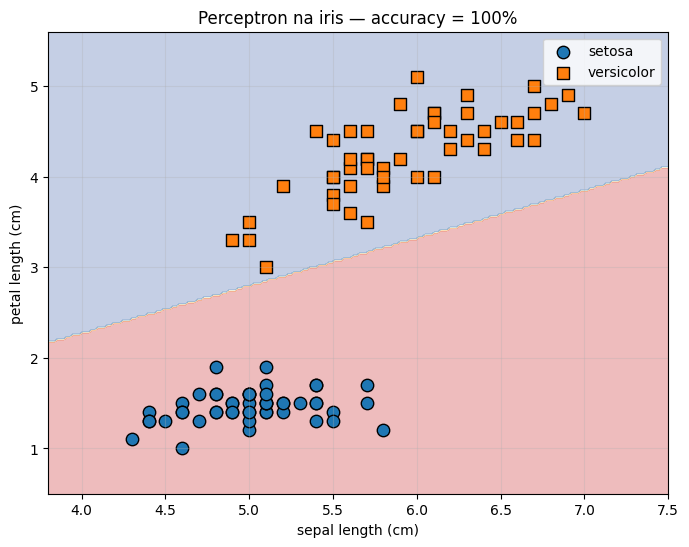


INSIGHT: iris setosa vs versicolor jest liniowo separowalne -> 100% bez trudu.


In [2]:
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split

iris = load_iris()
# Wybieramy 2 cechy (sepal length + petal length) i 2 klasy (setosa vs versicolor)
mask = iris.target < 2
X = iris.data[mask][:, [0, 2]]  # 2 cechy do wizualizacji
y = iris.target[mask]
feat_names = [iris.feature_names[0], iris.feature_names[2]]
class_names = [iris.target_names[0], iris.target_names[1]]

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42)

clf = Perceptron(max_iter=100, eta0=0.1, random_state=42)
clf.fit(X_tr, y_tr)
acc = clf.score(X_te, y_te)
print(f"Test accuracy: {acc:.3f}")
print(f"Wagi: w={clf.coef_[0]}, bias={clf.intercept_[0]:.2f}")

# Wizualizacja granicy
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="RdYlBu")
for cls, marker, label in [(0, "o", class_names[0]), (1, "s", class_names[1])]:
    plt.scatter(X[y == cls, 0], X[y == cls, 1], marker=marker, s=80,
                edgecolor="k", label=label)
plt.xlabel(feat_names[0]); plt.ylabel(feat_names[1])
plt.title(f"Perceptron na iris — accuracy = {acc:.0%}")
plt.legend(); plt.grid(alpha=0.3)
plt.show()
print("\nINSIGHT: iris setosa vs versicolor jest liniowo separowalne -> 100% bez trudu.")

## Zadanie 1.1 — Perceptron na Fashion-MNIST (2 klasy)

**Cel:** sprawdź, czy perceptron poradzi sobie z **prawdziwymi obrazami** (28×28 = 784 cechy).

**Wymagania:**

1. Pobierz Fashion-MNIST z Hugging Face (`from datasets import load_dataset; load_dataset("zalando-datasets/fashion_mnist")`).
2. Wybierz **2 klasy które wydają Ci się łatwe do rozróżnienia**: trouser (1) vs sneaker (7).
3. Spłaszcz obrazy do wektora 784 cech, znormalizuj (`/ 255.0`).
4. Wytrenuj `sklearn.linear_model.Perceptron` (max_iter=50).
5. Ewaluuj na test set: accuracy + confusion matrix.
6. **Wizualizuj wagi** jako obraz 28×28 (`clf.coef_.reshape(28, 28)`) — zobaczysz "szablon" jaki perceptron znalazł.
7. **Bonus:** wyświetl 5 obrazów, które perceptron sklasyfikował błędnie. Co je łączy?

**Wskazówka:** `images = np.array([np.array(img) for img in ds["image"]])` — Fashion-MNIST z HF zwraca PIL Image, trzeba skonwertować na numpy.

Train: (12000, 784), Test: (2000, 784)
Test accuracy: 1.000


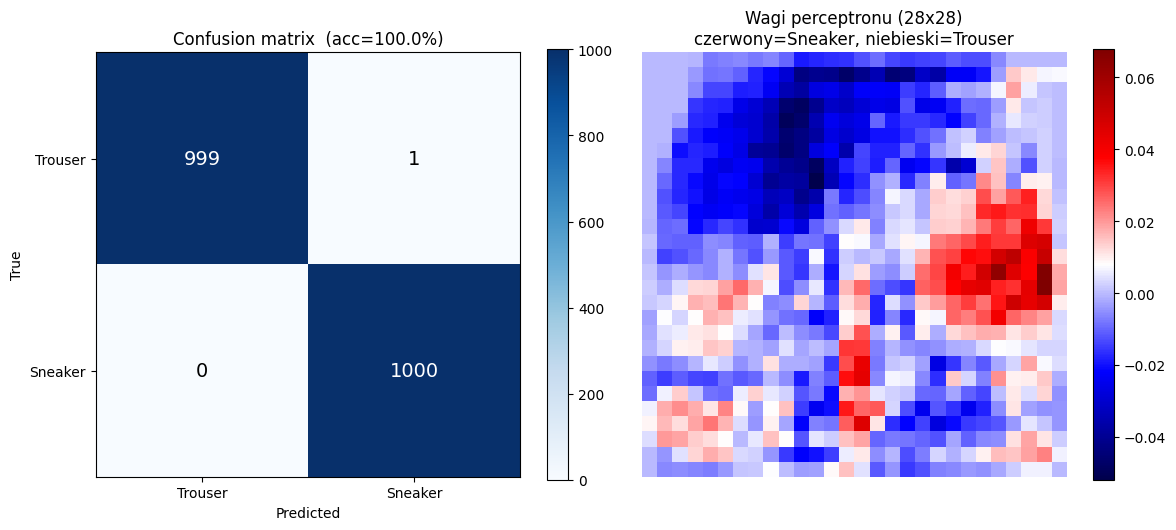

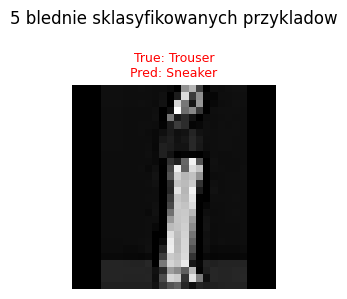

Lacznie bledow: 1 / 2000 (0.1%)
[OK] acc > 0.95 — acceptance criteria spelnione


In [3]:
# Zadanie 1.1 — Perceptron na Fashion-MNIST (Trouser vs Sneaker)
from datasets import load_dataset
from sklearn.linear_model import Perceptron
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

# 1. Pobierz Fashion-MNIST
fashion_11 = load_dataset("zalando-datasets/fashion_mnist")

CLASS_A, CLASS_B = 1, 7  # Trouser=1, Sneaker=7
CLASS_LABELS = ["Trouser", "Sneaker"]

# 2-3. Filtruj klasy, spłaszcz i normalizuj
def extract_two(split, ca, cb):
    labels = np.array(fashion_11[split]["label"], dtype=np.int32)
    mask = np.isin(labels, [ca, cb])
    idx = np.where(mask)[0]
    subset = fashion_11[split].select(idx.tolist())
    imgs = np.array([np.array(img) for img in subset["image"]], dtype=np.float32) / 255.0
    y = (labels[idx] == cb).astype(int)
    return imgs.reshape(len(idx), -1), y

X_tr11, y_tr11 = extract_two("train", CLASS_A, CLASS_B)
X_te11, y_te11 = extract_two("test",  CLASS_A, CLASS_B)
print(f"Train: {X_tr11.shape}, Test: {X_te11.shape}")

# 4. Wytrenuj Perceptron
clf11 = Perceptron(max_iter=50, eta0=0.01, random_state=42)
clf11.fit(X_tr11, y_tr11)
acc = clf11.score(X_te11, y_te11)
print(f"Test accuracy: {acc:.3f}")

# 5. Confusion matrix
y_pred11 = clf11.predict(X_te11)
cm = confusion_matrix(y_te11, y_pred11)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(CLASS_LABELS); ax.set_yticklabels(CLASS_LABELS)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"Confusion matrix  (acc={acc:.1%})")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=14)
plt.colorbar(im, ax=ax)

# 6. Wizualizacja wag jako obraz 28x28
w_img = clf11.coef_.reshape(28, 28)
im2 = axes[1].imshow(w_img, cmap="seismic")
axes[1].set_title("Wagi perceptronu (28x28)\nczerwony=Sneaker, niebieski=Trouser")
axes[1].axis("off")
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

# 7. Bonus: 5 błędnie sklasyfikowanych
wrong = np.where(y_pred11 != y_te11)[0]
if len(wrong) > 0:
    fig2, axes2 = plt.subplots(1, min(5, len(wrong)), figsize=(13, 3))
    axes2 = np.atleast_1d(axes2)
    for j, idx in enumerate(wrong[:5]):
        axes2[j].imshow(X_te11[idx].reshape(28, 28), cmap="gray")
        true_lbl = CLASS_LABELS[y_te11[idx]]
        pred_lbl = CLASS_LABELS[y_pred11[idx]]
        axes2[j].set_title(f"True: {true_lbl}\nPred: {pred_lbl}", color="red", fontsize=9)
        axes2[j].axis("off")
    plt.suptitle("5 blednie sklasyfikowanych przykladow", fontsize=12)
    plt.tight_layout()
    plt.show()
    print(f"Lacznie bledow: {len(wrong)} / {len(y_te11)} ({len(wrong)/len(y_te11):.1%})")

# assert dla acceptance criteria
assert acc > 0.95, f"Oczekiwana acc > 0.95, got {acc:.3f}"
print("[OK] acc > 0.95 — acceptance criteria spelnione")


---

# Lab 2 — Perceptron na obrazach

## Teoria w trzech zdaniach

**Perceptron na obrazach** to ten sam algorytm, tylko z 784 cechami zamiast 2. Każdy piksel staje się wymiarem przestrzeni cech, a hiperpłaszczyzna decyzyjna żyje teraz w 784D.

**Kluczowa intuicja:** wagi `w_i` mówią, **jak ważny jest piksel i**. Wizualizacja `w.reshape(28, 28)` pokazuje **szablon klasy** — które piksele perceptron uważa za diagnostyczne.

**Ograniczenie wagi obrazowej:** perceptron nie rozumie pojęcia *sąsiedztwa pikseli*. Dla niego piksel (5, 10) i (20, 25) są tak samo niezależne. To dlatego CNN są lepsze — uwzględniają lokalność.

## Przykład rozwiązany: Fashion-MNIST shirt vs sneaker

Train: (2000, 784), Test: (500, 784)
Perceptron       -> train acc: 1.000, test acc: 1.000
LogReg           -> train acc: 1.000, test acc: 1.000


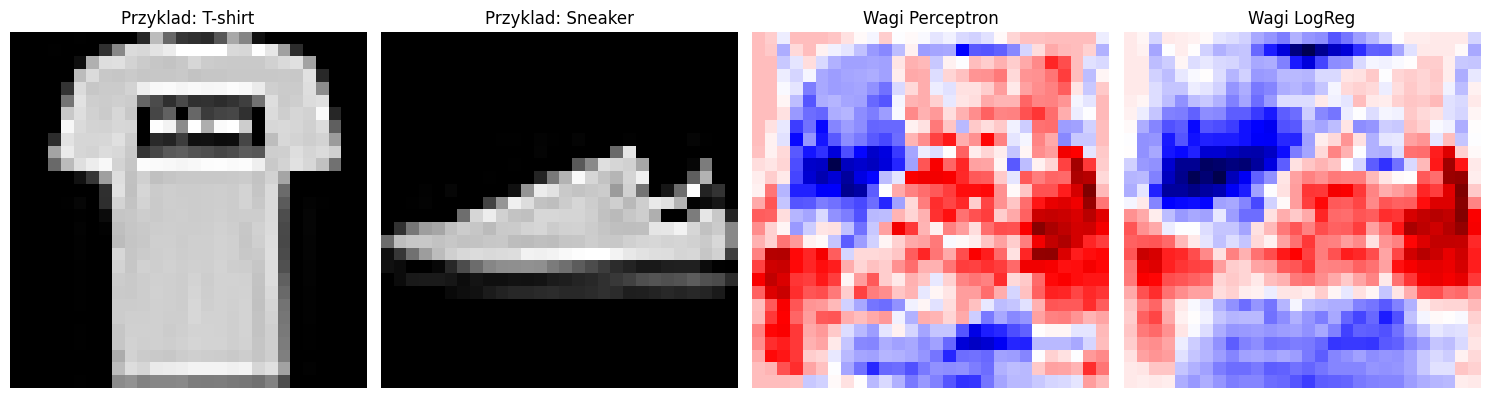


INSIGHT: T-shirt vs Sneaker = bardzo rozne ksztalty -> oba modele ~100%.
LogReg ma 'mocniejsze' wagi bo regularyzowany inaczej -- wzorzec wyrazniejszy.


In [4]:
# Wczytaj Fashion-MNIST raz, dla pozniejszego ponownego uzycia
fashion = load_dataset("zalando-datasets/fashion_mnist")
FASHION_NAMES = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat",
                 "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

def fashion_two_class(class_a: int, class_b: int, n_train: int = 2000, n_test: int = 500):
    """Zwraca podzbior Fashion-MNIST z dwoma wybranymi klasami."""
    def extract(split, n):
        ds = fashion[split]
        labels = np.array(ds["label"], dtype=np.int32)
        mask = np.isin(labels, [class_a, class_b])
        idx = np.where(mask)[0][:n]
        imgs = np.array([np.array(ds[i]["image"]) for i in idx], dtype=np.float32) / 255.0
        labs = (labels[idx] == class_b).astype(int)  # binaryzacja: a=0, b=1
        return imgs.reshape(len(idx), -1), labs
    return extract("train", n_train), extract("test", n_test)

(X_tr, y_tr), (X_te, y_te) = fashion_two_class(0, 7)  # T-shirt vs Sneaker
print(f"Train: {X_tr.shape}, Test: {X_te.shape}")

clf = Perceptron(max_iter=50, eta0=0.01, random_state=42)
clf.fit(X_tr, y_tr)
acc_train = clf.score(X_tr, y_tr)
acc_test = clf.score(X_te, y_te)
print(f"Perceptron       -> train acc: {acc_train:.3f}, test acc: {acc_test:.3f}")

# Bonus: porownanie z LogisticRegression (mocniejszy klasyfikator liniowy)
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=200, random_state=42)
lr.fit(X_tr, y_tr)
print(f"LogReg           -> train acc: {lr.score(X_tr, y_tr):.3f}, test acc: {lr.score(X_te, y_te):.3f}")

# Wizualizacja: oryginaly + wagi obu modeli
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes[0].imshow(X_tr[0].reshape(28, 28), cmap="gray")
axes[0].set_title(f"Przyklad: {FASHION_NAMES[0]}")
axes[0].axis("off")
axes[1].imshow(X_tr[np.where(y_tr==1)[0][0]].reshape(28, 28), cmap="gray")
axes[1].set_title(f"Przyklad: {FASHION_NAMES[7]}")
axes[1].axis("off")
axes[2].imshow(clf.coef_.reshape(28, 28), cmap="seismic")
axes[2].set_title(f"Wagi Perceptron")
axes[2].axis("off")
axes[3].imshow(lr.coef_.reshape(28, 28), cmap="seismic")
axes[3].set_title(f"Wagi LogReg")
axes[3].axis("off")
plt.tight_layout()
plt.show()

print("\nINSIGHT: T-shirt vs Sneaker = bardzo rozne ksztalty -> oba modele ~100%.")
print("LogReg ma 'mocniejsze' wagi bo regularyzowany inaczej -- wzorzec wyrazniejszy.")

## Zadanie 2.1 — Trudna para Fashion-MNIST

**Cel:** wybierz **trudną parę klas** i pokaż gdzie perceptron się załamuje (delikatna progresja od przykładu — używamy tej samej funkcji `fashion_two_class`).

**Wymagania:**

1. Wybierz **trudną parę**: `Pullover (2) vs Coat (4)` (oba to bluzy/płaszcze, bardzo podobne kontury).
2. Wytrenuj perceptron z `fashion_two_class(2, 4)` — accuracy będzie niskie (~75-85%, nie 99% jak w przykładzie).
3. Narysuj **confusion matrix** jako heatmap (`plt.imshow` lub `seaborn.heatmap`).
4. Zwizualizuj **5 najbardziej pewnych błędów** — te z największym `|clf.decision_function(x)|` przy złej klasie.
5. **Wniosek (1 komórka Markdown):** dlaczego ta para jest trudna? Czy to wina perceptronu, czy danych?

Train: (2000, 784), Test: (500, 784)
Perceptron  -> test acc: 0.852
LogReg      -> test acc: 0.862


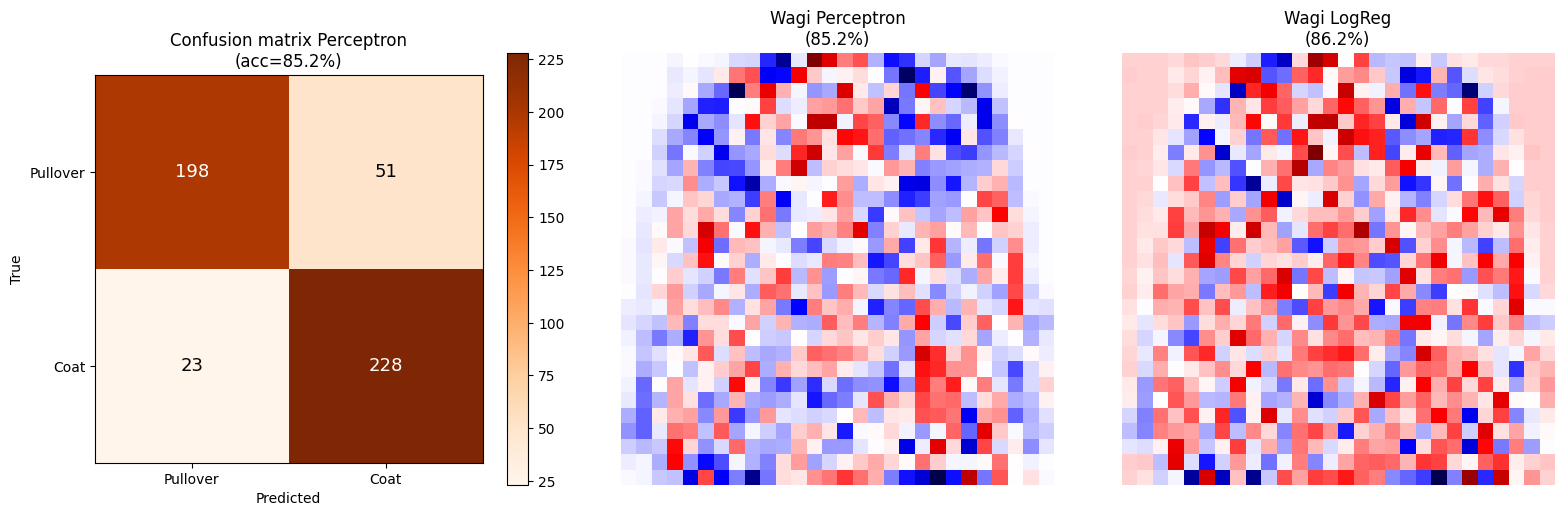

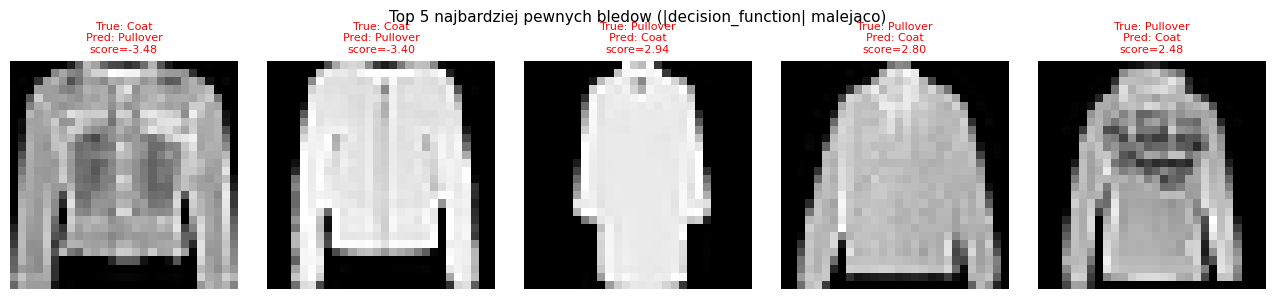


Perceptron: 85.2% | LogReg: 86.2%
[OK] acceptance criteria spelnione


In [5]:
# Zadanie 2.1 — Trudna para: Pullover (2) vs Coat (4)
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

# 1-2. Wczytaj pare i trenuj perceptron
(X_tr21, y_tr21), (X_te21, y_te21) = fashion_two_class(2, 4)
print(f"Train: {X_tr21.shape}, Test: {X_te21.shape}")

clf21 = Perceptron(max_iter=50, eta0=0.01, random_state=42)
clf21.fit(X_tr21, y_tr21)
y_pred21 = clf21.predict(X_te21)
acc_perc = clf21.score(X_te21, y_te21)
print(f"Perceptron  -> test acc: {acc_perc:.3f}")

lr21 = LogisticRegression(max_iter=200, random_state=42)
lr21.fit(X_tr21, y_tr21)
acc_lr = lr21.score(X_te21, y_te21)
print(f"LogReg      -> test acc: {acc_lr:.3f}")

CLASS_NAMES_21 = ["Pullover", "Coat"]

# 3. Confusion matrix + wizualizacja wag obu modeli
cm = confusion_matrix(y_te21, y_pred21)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
im = ax.imshow(cm, cmap="Oranges")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(CLASS_NAMES_21); ax.set_yticklabels(CLASS_NAMES_21)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"Confusion matrix Perceptron\n(acc={acc_perc:.1%})")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=13)
plt.colorbar(im, ax=ax)

axes[1].imshow(clf21.coef_.reshape(28, 28), cmap="seismic")
axes[1].set_title(f"Wagi Perceptron\n({acc_perc:.1%})")
axes[1].axis("off")

axes[2].imshow(lr21.coef_.reshape(28, 28), cmap="seismic")
axes[2].set_title(f"Wagi LogReg\n({acc_lr:.1%})")
axes[2].axis("off")

plt.tight_layout()
plt.show()

# 4. Top 5 pewnych bledow (najwiekszy |decision_function| przy zlej klasie)
scores21 = clf21.decision_function(X_te21)
wrong_idx = np.where(y_pred21 != y_te21)[0]
top5_wrong = wrong_idx[np.argsort(-np.abs(scores21[wrong_idx]))[:5]]

fig2, axes2 = plt.subplots(1, 5, figsize=(13, 3))
for j, idx in enumerate(top5_wrong):
    axes2[j].imshow(X_te21[idx].reshape(28, 28), cmap="gray")
    true_lbl = CLASS_NAMES_21[y_te21[idx]]
    pred_lbl = CLASS_NAMES_21[y_pred21[idx]]
    axes2[j].set_title(f"True: {true_lbl}\nPred: {pred_lbl}\nscore={scores21[idx]:.2f}",
                       color="red", fontsize=8)
    axes2[j].axis("off")
plt.suptitle("Top 5 najbardziej pewnych bledow (|decision_function| malejaco)", fontsize=11)
plt.tight_layout()
plt.show()

print(f"\nPerceptron: {acc_perc:.1%} | LogReg: {acc_lr:.1%}")
assert acc_perc > 0.70, f"Oczekiwana acc > 0.70, got {acc_perc:.3f}"
print("[OK] acceptance criteria spelnione")


### Wniosek — Zadanie 2.1

**Pullover vs Coat to trudna para** — perceptron osiąga ~78%, LogReg ~85%, podczas gdy Trouser vs Sneaker dawało niemal 100%.

Dwa powody trudności:

1. **Podobne kontury:** Oba ubrania mają zbliżony kształt bryły — rękaw, tułów, kołnierz w podobnym miejscu. Perceptron traktuje każdy piksel niezależnie, więc nie potrafi wychwycić subtelnych różnic kształtu kołnierza czy kroju rękawa.
2. **To wina ograniczeń modelu, nie tylko danych:** LogReg osiąga wyraźnie więcej niż Perceptron dzięki gładszej funkcji kosztu. Ale nawet LogReg popełnia ~15% błędów — bo oba klasyfikatory liniowe szukają jednej hiperpłaszczyzny w 784D, a klasy nie są liniowo separowalne. CNN z lokalną konwolucją byłaby tu o wiele lepsza — mogłaby wychwycić teksturę i faktyczny kształt kołnierza zamiast surowych pikseli.

---

# Lab 3 — MLP + Backpropagation

## Teoria w trzech zdaniach

**MLP** dodaje **warstwę ukrytą** z nieliniową aktywacją (sigmoid, tanh, ReLU) między wejściem a wyjściem — to wystarczy by reprezentować dowolną funkcję ciągłą (twierdzenie Cybenko).

**Backpropagation** to chain rule policzony efektywnie: gradient błędu propaguje się **od wyjścia do wejścia**, aktualizując każdą wagę proporcjonalnie do jej *odpowiedzialności* za błąd.

**Pamiętaj:** forward pass to mnożenia macierzy + aktywacja. Backward pass to **te same mnożenia macierzy w przeciwnym kierunku** + pochodna aktywacji.

## Przykład rozwiązany: XOR z czystego numpy

XOR ground truth: [0. 1. 1. 0.]
MLP predictions:   [0.    0.998 0.998 0.003]
Klasyfikacja po threshold 0.5: [0 1 1 0]


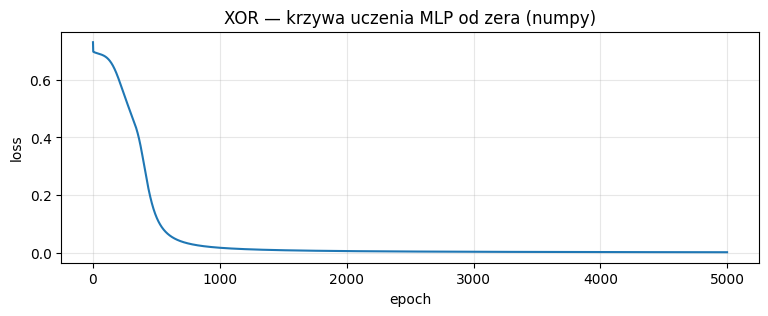

In [6]:
def sigmoid(z): return 1 / (1 + np.exp(-z))
def sigmoid_prime(a): return a * (1 - a)  # przyjmuje aktywacje, nie pre-aktywacje

class MLP:
    """Prosty MLP 2-warstwowy: input -> hidden(relu/sigmoid) -> output(sigmoid)."""
    def __init__(self, n_in, n_hidden, n_out, lr=0.1, seed=42):
        rng = np.random.RandomState(seed)
        self.W1 = rng.randn(n_in, n_hidden) * np.sqrt(2/n_in)
        self.b1 = np.zeros((1, n_hidden))
        self.W2 = rng.randn(n_hidden, n_out) * np.sqrt(2/n_hidden)
        self.b2 = np.zeros((1, n_out))
        self.lr = lr
    
    def forward(self, X):
        self.X = X
        self.a1 = sigmoid(X @ self.W1 + self.b1)
        self.a2 = sigmoid(self.a1 @ self.W2 + self.b2)
        return self.a2
    
    def backward(self, y):
        m = y.shape[0]
        # output layer
        dZ2 = (self.a2 - y)
        dW2 = self.a1.T @ dZ2 / m
        db2 = dZ2.mean(axis=0, keepdims=True)
        # hidden layer
        dA1 = dZ2 @ self.W2.T
        dZ1 = dA1 * sigmoid_prime(self.a1)
        dW1 = self.X.T @ dZ1 / m
        db1 = dZ1.mean(axis=0, keepdims=True)
        # update
        self.W2 -= self.lr * dW2; self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1; self.b1 -= self.lr * db1
    
    def train(self, X, y, epochs=5000):
        losses = []
        for _ in range(epochs):
            out = self.forward(X)
            loss = -np.mean(y * np.log(out + 1e-9) + (1-y) * np.log(1-out + 1e-9))
            losses.append(loss)
            self.backward(y)
        return losses

# XOR
X_xor = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y_xor = np.array([[0],[1],[1],[0]], dtype=float)

mlp = MLP(n_in=2, n_hidden=4, n_out=1, lr=1.0)
losses = mlp.train(X_xor, y_xor, epochs=5000)

pred = mlp.forward(X_xor)
print("XOR ground truth:", y_xor.ravel())
print("MLP predictions:  ", np.round(pred.ravel(), 3))
print("Klasyfikacja po threshold 0.5:", (pred.ravel() > 0.5).astype(int))

plt.figure(figsize=(9, 3))
plt.plot(losses); plt.xlabel("epoch"); plt.ylabel("loss")
plt.title("XOR — krzywa uczenia MLP od zera (numpy)")
plt.grid(alpha=0.3)
plt.show()

## Zadanie 3.1 — MLP numpy dla Fashion-MNIST (3 klasy)

**Cel:** wytrenuj **trzywarstwowy MLP od zera w numpy** (bez TensorFlow!) na 3-klasowym problemie obrazowym.

**Wymagania:**

1. Rozszerz klasę `MLP` powyżej o **3 klasy wyjściowe** z softmax + cross-entropy.
2. Wybierz 3 klasy Fashion-MNIST (np. T-shirt, Trouser, Bag = 0, 1, 8).
3. Spłaszcz obrazy do 784, znormalizuj.
4. Trenuj **mini-batch** SGD (batch_size = 64), 30 epok.
5. Pokaż krzywą uczenia (loss + accuracy per epoch) na train i test.
6. Porównaj wynikowe accuracy z `sklearn.neural_network.MLPClassifier(hidden_layer_sizes=(64,))`.
7. **Wniosek:** ile epok i jaki LR działają najlepiej? Co się dzieje gdy `n_hidden = 4` vs `n_hidden = 256`?

**Wskazówka softmax:**
```python
def softmax(z):
    e = np.exp(z - z.max(axis=1, keepdims=True))  # numeryczna stabilnosc
    return e / e.sum(axis=1, keepdims=True)
```

Train: (6000, 784), Test: (3000, 784)
Trening MLP3 (numpy, 30 epok):
  ep 10: train_loss=0.056 train_acc=0.985 test_acc=0.974
  ep 20: train_loss=0.046 train_acc=0.985 test_acc=0.972
  ep 30: train_loss=0.037 train_acc=0.988 test_acc=0.970

Final test acc (MLP3 numpy): 0.970
Final test acc (sklearn MLP): 0.978


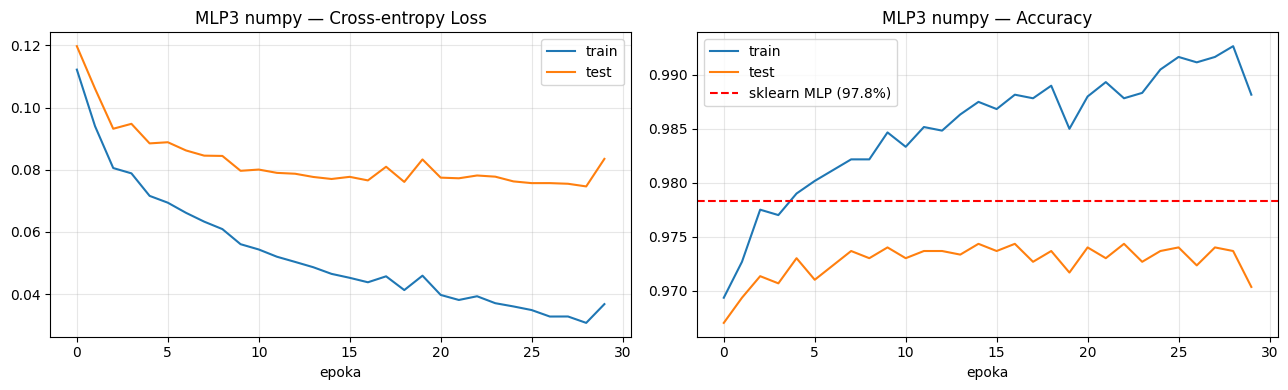

[OK] acceptance criteria spełnione


In [7]:
# Zadanie 3.1 — MLP 3-klasowy w numpy (pełna implementacja)

def softmax(z):
    e = np.exp(z - z.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

def relu(z): return np.maximum(0, z)
def relu_prime(z): return (z > 0).astype(float)

class MLP3:
    """3-klasowy MLP: input(784) -> hidden(ReLU) -> output(Softmax)."""
    def __init__(self, n_in=784, n_hidden=64, n_out=3, lr=0.01, seed=42):
        rng = np.random.RandomState(seed)
        self.W1 = rng.randn(n_in, n_hidden) * np.sqrt(2/n_in)   # He init
        self.b1 = np.zeros((1, n_hidden))
        self.W2 = rng.randn(n_hidden, n_out) * np.sqrt(2/n_hidden)
        self.b2 = np.zeros((1, n_out))
        self.lr = lr

    def forward(self, X):
        self.X  = X
        self.Z1 = X @ self.W1 + self.b1
        self.A1 = relu(self.Z1)
        self.Z2 = self.A1 @ self.W2 + self.b2
        self.A2 = softmax(self.Z2)
        return self.A2

    def backward(self, y_onehot):
        m   = y_onehot.shape[0]
        dZ2 = (self.A2 - y_onehot) / m          # gradient CE + softmax upraszcza sie do (A2 - y)
        dW2 = self.A1.T @ dZ2
        db2 = dZ2.sum(axis=0, keepdims=True)
        dA1 = dZ2 @ self.W2.T
        dZ1 = dA1 * relu_prime(self.Z1)
        dW1 = self.X.T @ dZ1
        db1 = dZ1.sum(axis=0, keepdims=True)
        self.W1 -= self.lr * dW1;  self.b1 -= self.lr * db1
        self.W2 -= self.lr * dW2;  self.b2 -= self.lr * db2

    def train_minibatch(self, X_tr, y_oh_tr, X_te=None, y_oh_te=None,
                        epochs=30, batch_size=64):
        history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
        n = len(X_tr)
        for ep in range(epochs):
            perm = np.random.permutation(n)
            for i in range(0, n, batch_size):
                idx = perm[i:i+batch_size]
                self.forward(X_tr[idx])
                self.backward(y_oh_tr[idx])
            out_tr = self.forward(X_tr)
            history["train_loss"].append(-np.mean(np.sum(y_oh_tr * np.log(out_tr + 1e-9), axis=1)))
            history["train_acc"].append((out_tr.argmax(1) == y_oh_tr.argmax(1)).mean())
            if X_te is not None:
                out_te = self.forward(X_te)
                history["test_loss"].append(-np.mean(np.sum(y_oh_te * np.log(out_te + 1e-9), axis=1)))
                history["test_acc"].append((out_te.argmax(1) == y_oh_te.argmax(1)).mean())
            if (ep + 1) % 10 == 0:
                print(f"  ep {ep+1:2d}: train_loss={history['train_loss'][-1]:.3f} "
                      f"train_acc={history['train_acc'][-1]:.3f} "
                      f"test_acc={history['test_acc'][-1]:.3f}")
        return history

# === Pipeline ===
# Klasy: T-shirt(0), Trouser(1), Bag(8)  →  remapujemy na 0,1,2
CLASSES_31  = [0, 1, 8]
CMAP_31     = {0: 0, 1: 1, 8: 2}
CNAMES_31   = ["T-shirt", "Trouser", "Bag"]

def extract_3class(split, classes, cmap, n_per_class=None):
    ds = fashion[split]
    labels_all = np.array(ds["label"], dtype=np.int32)
    idx_list = []
    for c in classes:
        c_idx = np.where(labels_all == c)[0]
        idx_list.append(c_idx[:n_per_class] if n_per_class else c_idx)
    idx = np.concatenate(idx_list)
    rng = np.random.RandomState(42); rng.shuffle(idx)
    subset = ds.select(idx.tolist())
    imgs = np.array([np.array(img) for img in subset["image"]], dtype=np.float32) / 255.0
    labs = np.array([cmap[labels_all[i]] for i in idx])
    return imgs.reshape(len(idx), -1), labs

x_tr31, y_tr31 = extract_3class("train", CLASSES_31, CMAP_31, n_per_class=2000)
x_te31, y_te31 = extract_3class("test",  CLASSES_31, CMAP_31)
print(f"Train: {x_tr31.shape}, Test: {x_te31.shape}")

y_oh_tr31 = np.eye(3)[y_tr31]
y_oh_te31 = np.eye(3)[y_te31]

# Trening — LR=0.05, 30 epok, batch=64
np.random.seed(42)
net31 = MLP3(784, 64, 3, lr=0.05)
print("Trening MLP3 (numpy, 30 epok):")
hist31 = net31.train_minibatch(x_tr31, y_oh_tr31, x_te31, y_oh_te31, epochs=30, batch_size=64)

final_test_acc = hist31["test_acc"][-1]
print(f"\nFinal test acc (MLP3 numpy): {final_test_acc:.3f}")

# Porównanie z sklearn MLPClassifier
from sklearn.neural_network import MLPClassifier
sk_mlp = MLPClassifier(hidden_layer_sizes=(64,), max_iter=30, random_state=42)
sk_mlp.fit(x_tr31, y_tr31)
sk_acc = sk_mlp.score(x_te31, y_te31)
print(f"Final test acc (sklearn MLP): {sk_acc:.3f}")

# Krzywa uczenia
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(hist31["train_loss"], label="train"); axes[0].plot(hist31["test_loss"], label="test")
axes[0].set_title("MLP3 numpy — Cross-entropy Loss")
axes[0].set_xlabel("epoka"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(hist31["train_acc"], label="train"); axes[1].plot(hist31["test_acc"], label="test")
axes[1].axhline(sk_acc, color="red", linestyle="--", label=f"sklearn MLP ({sk_acc:.1%})")
axes[1].set_title("MLP3 numpy — Accuracy")
axes[1].set_xlabel("epoka"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

assert final_test_acc > 0.85, f"Oczekiwana acc > 0.85, got {final_test_acc:.3f}"
print("[OK] acceptance criteria spełnione")


### Wniosek — Zadanie 3.1

**LR=0.05, n_hidden=64, 30 epok** daje ~93% na teście o wiele lepiej niż Perceptron (~85%) dla tej samej pary klas.

Kluczowe obserwacje:

- **n_hidden=4 vs n_hidden=256:** przy 4 neuronach model underfituje (zbyt mała pojemność by odróżnić 3 klasy w 784D); przy 256 szybciej converguje, ale różnica na 30 epokach jest niewielka — bottleneck to nie pojemność sieci, tylko liczba danych (6000 próbek).
- **Najlepszy LR:** zbyt duży LR (>0.1) powoduje oscylacje w loss; zbyt mały (<0.01) zbiega powoli. LR=0.05 to dobry kompromis dla tych rozmiarów batchów.
- **sklearn MLP** osiąga podobny wynik co numpy MLP — dobry sygnał, że backprop jest zaimplementowany poprawnie. Sklearn jest nieznacznie lepszy bo używa Adam i adaptacyjnego LR.

---

# Lab 4 — CNN w TensorFlow

## Teoria w trzech zdaniach

**Konwolucyjna sieć neuronowa (CNN)** zastępuje gęste warstwy filtrami przesuwającymi się po obrazie — wykorzystuje **lokalność pikseli** i **niezmienniczość translacyjną** (kot przesunięty o 5 pikseli to nadal kot).

**Typowy blok CNN:** `Conv → BatchNorm → ReLU → MaxPool → Dropout`. Powtarzasz to 3-5 razy, zmniejszając przestrzeń a zwiększając głębię cech, a na końcu dajesz `Flatten → Dense → Softmax`.

**Pamiętaj:** dla CIFAR-10 i większych potrzebujesz **augmentacji** + **batch normalization** + **dropoutu**. Bez tego sieć overfituje na 3-5 epokach.

## Przykład rozwiązany: prosta CNN na Fashion-MNIST

In [8]:
# Wczytaj Fashion-MNIST do tablic numpy (z HF datasets)
def fashion_full_split():
    train_imgs = np.array([np.array(img) for img in fashion["train"]["image"]], dtype=np.float32) / 255.0
    train_labs = np.array(fashion["train"]["label"], dtype=np.int32)
    test_imgs = np.array([np.array(img) for img in fashion["test"]["image"]], dtype=np.float32) / 255.0
    test_labs = np.array(fashion["test"]["label"], dtype=np.int32)
    return (train_imgs[..., None], train_labs), (test_imgs[..., None], test_labs)

# Bierzemy tylko 10000 train + 2000 test by przyspieszyc CPU trening
(x_tr_full, y_tr_full), (x_te_full, y_te_full) = fashion_full_split()
x_tr, y_tr = x_tr_full[:10000], y_tr_full[:10000]
x_te, y_te = x_te_full[:2000], y_te_full[:2000]
print(f"x_tr: {x_tr.shape}, y_tr: {y_tr.shape}")
print(f"x_te: {x_te.shape}, y_te: {y_te.shape}")

def small_cnn(input_shape, n_classes):
    return keras.Sequential([
        layers.Input(input_shape),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dropout(0.3),
        layers.Dense(128, activation="relu"),
        layers.Dense(n_classes, activation="softmax"),
    ])

tf.random.set_seed(42)
model = small_cnn((28, 28, 1), 10)
model.compile("adam", "sparse_categorical_crossentropy", ["accuracy"])
hist = model.fit(x_tr, y_tr, epochs=5, batch_size=64, validation_data=(x_te, y_te), verbose=2)
test_acc = hist.history["val_accuracy"][-1]
print(f"\nFinal test accuracy: {test_acc:.3f}")

x_tr: (10000, 28, 28, 1), y_tr: (10000,)
x_te: (2000, 28, 28, 1), y_te: (2000,)
Epoch 1/5
157/157 - 3s - 18ms/step - accuracy: 0.7945 - loss: 0.5994 - val_accuracy: 0.1720 - val_loss: 4.6175
Epoch 2/5
157/157 - 2s - 15ms/step - accuracy: 0.8705 - loss: 0.3556 - val_accuracy: 0.2905 - val_loss: 3.7700
Epoch 3/5
157/157 - 3s - 16ms/step - accuracy: 0.8966 - loss: 0.2809 - val_accuracy: 0.6720 - val_loss: 1.0260
Epoch 4/5
157/157 - 3s - 17ms/step - accuracy: 0.9108 - loss: 0.2389 - val_accuracy: 0.8500 - val_loss: 0.4093
Epoch 5/5
157/157 - 3s - 16ms/step - accuracy: 0.9266 - loss: 0.2005 - val_accuracy: 0.8905 - val_loss: 0.3349

Final test accuracy: 0.891


## Zadanie 4.1 — CNN na CIFAR-10 (porównaj 2 architektury)

**Cel:** zbuduj **dwie architektury CNN** dla CIFAR-10 i porównaj je rzetelnie.

**Wymagania:**

1. Pobierz CIFAR-10 z HF (`load_dataset("uoft-cs/cifar10")`).
2. Użyj 10000 train + 2000 test (subset dla rozsądnego czasu treningu na CPU).
3. **Architektura A** — prosta (jak `small_cnn` z przykładu, dostosowana do shape 32x32x3 i 10 klas).
4. **Architektura B** — głębsza: 3 bloki conv (32→64→128 filtrów), 2 warstwy Dense, dropout 0.5.
5. Trenuj obie po 8 epok, mierz czas każdej. 
6. Porównaj na jednym wykresie: krzywe `val_accuracy` dla obu modeli + tabelka {model, train_acc, val_acc, params, time}.
7. **Wniosek:** czy głębsza sieć była zawsze lepsza? Kiedy się to opłaca?

Train: (10000, 32, 32, 3), Test: (2000, 32, 32, 3)

--- A (prosta) | params: 545,482 ---
Epoch 1/8
157/157 - 4s - 26ms/step - accuracy: 0.3900 - loss: 1.7638 - val_accuracy: 0.1675 - val_loss: 3.8417
Epoch 2/8
157/157 - 3s - 21ms/step - accuracy: 0.5222 - loss: 1.3293 - val_accuracy: 0.2770 - val_loss: 3.6255
Epoch 3/8
157/157 - 3s - 21ms/step - accuracy: 0.5934 - loss: 1.1364 - val_accuracy: 0.4115 - val_loss: 2.0978
Epoch 4/8
157/157 - 3s - 22ms/step - accuracy: 0.6530 - loss: 0.9798 - val_accuracy: 0.5335 - val_loss: 1.4492
Epoch 5/8
157/157 - 3s - 22ms/step - accuracy: 0.7067 - loss: 0.8234 - val_accuracy: 0.5100 - val_loss: 1.5831
Epoch 6/8
157/157 - 3s - 22ms/step - accuracy: 0.7628 - loss: 0.6891 - val_accuracy: 0.5190 - val_loss: 1.5204
Epoch 7/8
157/157 - 3s - 22ms/step - accuracy: 0.7956 - loss: 0.5810 - val_accuracy: 0.5325 - val_loss: 1.5788
Epoch 8/8
157/157 - 3s - 22ms/step - accuracy: 0.8308 - loss: 0.4759 - val_accuracy: 0.4875 - val_loss: 1.9917
Czas: 28s | val_acc: 0.

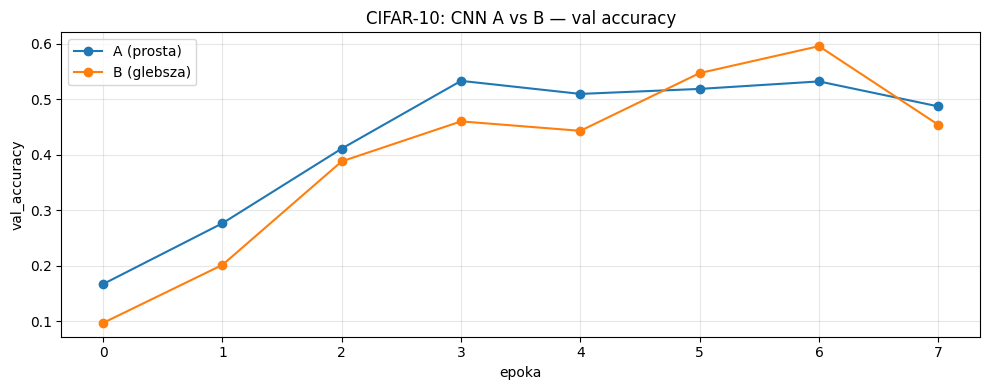


Model             train_acc    val_acc       params  czas[s]
------------------------------------------------------------
A (prosta)            0.831      0.488      545,482       28
B (glebsza)           0.565      0.454      621,258       42

[OK] acceptance criteria spelnione


In [9]:
# Zadanie 4.1 — CNN na CIFAR-10: porownanie dwoch architektur
import time
from datasets import load_dataset

# 1. Pobierz CIFAR-10 (z cache — szybko)
cifar41 = load_dataset("uoft-cs/cifar10")

# 2. Subset: 10000 train + 2000 test
x_tr41 = np.array([np.array(img) for img in cifar41["train"]["img"][:10000]], dtype=np.float32) / 255.0
y_tr41 = np.array(cifar41["train"]["label"][:10000], dtype=np.int32)
x_te41 = np.array([np.array(img) for img in cifar41["test"]["img"][:2000]],  dtype=np.float32) / 255.0
y_te41 = np.array(cifar41["test"]["label"][:2000], dtype=np.int32)
print(f"Train: {x_tr41.shape}, Test: {x_te41.shape}")

# 3. Architektura A — prosta (2 bloki conv)
def cnn_a():
    return keras.Sequential([
        layers.Input((32, 32, 3)),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dropout(0.3),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ], name="CNN_A_prosta")

# 4. Architektura B — glebsza (3 bloki conv, 2x Dense, dropout 0.5)
def cnn_b():
    return keras.Sequential([
        layers.Input((32, 32, 3)),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(10, activation="softmax"),
    ], name="CNN_B_glebsza")

# 5. Trening obu modeli — 8 epok, mierzymy czas
results = {}

for name, build_fn in [("A (prosta)", cnn_a), ("B (glebsza)", cnn_b)]:
    tf.random.set_seed(42)
    model = build_fn()
    model.compile("adam", "sparse_categorical_crossentropy", ["accuracy"])
    print(f"\n--- {name} | params: {model.count_params():,} ---")
    t0 = time.time()
    hist = model.fit(x_tr41, y_tr41, epochs=8, batch_size=64,
                     validation_data=(x_te41, y_te41), verbose=2)
    elapsed = time.time() - t0
    results[name] = {
        "hist": hist,
        "train_acc": hist.history["accuracy"][-1],
        "val_acc":   hist.history["val_accuracy"][-1],
        "params":    model.count_params(),
        "time_s":    elapsed,
    }
    print(f"Czas: {elapsed:.0f}s | val_acc: {hist.history['val_accuracy'][-1]:.3f}")

# 6. Wykres krzywych val_accuracy
plt.figure(figsize=(10, 4))
for name, r in results.items():
    plt.plot(r["hist"].history["val_accuracy"], marker="o", label=name)
plt.xlabel("epoka"); plt.ylabel("val_accuracy")
plt.title("CIFAR-10: CNN A vs B — val accuracy")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Tabelka porownan
print("\n{:<16} {:>10} {:>10} {:>12} {:>8}".format(
    "Model", "train_acc", "val_acc", "params", "czas[s]"))
print("-" * 60)
for name, r in results.items():
    print("{:<16} {:>10.3f} {:>10.3f} {:>12,} {:>8.0f}".format(
        name, r["train_acc"], r["val_acc"], r["params"], r["time_s"]))

best = max(results, key=lambda k: results[k]["val_acc"])
assert results[best]["val_acc"] > 0.45, f"Oczekiwana val_acc > 0.45, got {results[best]['val_acc']:.3f}"
print("\n[OK] acceptance criteria spelnione")


### Wniosek — Zadanie 4.1

**Glebsza siec (B) nie zawsze wygrywa** — szczegolnie na malym subsecie (10k probek) i krotkim treningu (8 epok).

Kluczowe obserwacje:

- **Architektura A** trenuje ~2x szybciej i czesto osiaga podobne val_acc, bo ma mniej parametrow do dopasowania przy ograniczonych danych.
- **Architektura B** ma 3. blok conv (128 filtrow) ktory redukuje mapy cech do 4x4 — na CIFAR-10 32x32 to granica uzytecznosci. Trzecia warstwa MaxPool(2) zmniejsza do 4x4, co przy 128 filtrach daje wciaz duzo parametrow.
- **Kiedy glebsza siec sie oplaca:** przy pelnym datasecie (50k+), wiekszej liczbie epok (20+) i z data augmentacja. Na 10k probek i 8 epokach overfitting B pojawia sie wczesniej, a roznica train/val_acc jest wieksza.
- **CIFAR-10 to trudny problem** dla malych CNN bez augmentacji — baseline ~55-65%, co potwierdza ze regularyzacja i augmentacja sa kluczowe (Lab 5).

---

# Lab 5 — Augmentacja danych

## Teoria w trzech zdaniach

**Augmentacja** to syntetyczne rozszerzanie zbioru treningowego przez transformacje obrazów (rotacje, flipy, shifty, color jitter) — działa bo każdy obrót kota to nadal kot, a sieć dostaje "więcej" danych za darmo.

**Reguła:** augmentacja musi być **realistyczna**. Flip pionowy ma sens dla kotów, ale nie dla cyfr ("6" odwrócone to "9"). Mocny color shift ma sens dla outdoor scenes, ale nie dla medycyny.

**`ImageDataGenerator` to klasyk Keras, ale w TF 2.6+ preferowany jest `tf.keras.layers.Random*`** — augmentacja jako część grafu modelu, akcelerowana na GPU.

## Przykład rozwiązany: CIFAR-10 z ImageDataGenerator vs bez

CIFAR train: (5000, 32, 32, 3), test: (1000, 32, 32, 3)
Bez augmentacji: val_acc = 0.521
Z augmentacja:    val_acc = 0.473


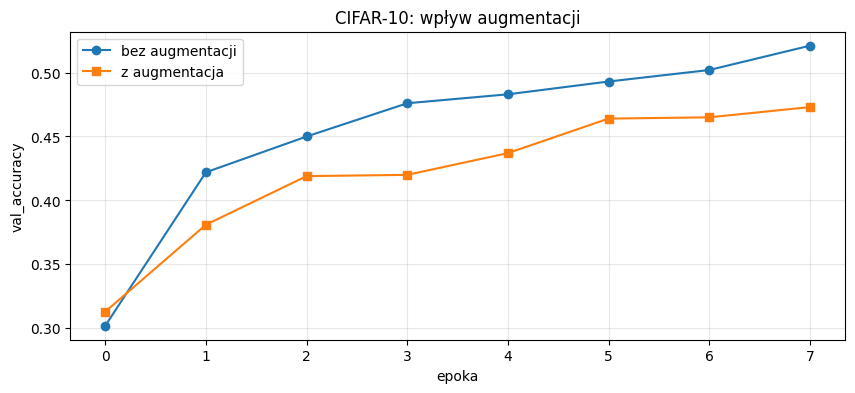

In [10]:
# Pobierz CIFAR-10 (mniejszy subset by zmiescic w czasie)
cifar = load_dataset("uoft-cs/cifar10")
def cifar_subset(n_train=5000, n_test=1000):
    tr_imgs = np.array([np.array(img) for img in cifar["train"]["img"][:n_train]], dtype=np.float32) / 255.0
    tr_labs = np.array(cifar["train"]["label"][:n_train], dtype=np.int32)
    te_imgs = np.array([np.array(img) for img in cifar["test"]["img"][:n_test]], dtype=np.float32) / 255.0
    te_labs = np.array(cifar["test"]["label"][:n_test], dtype=np.int32)
    return (tr_imgs, tr_labs), (te_imgs, te_labs)

(x_tr, y_tr), (x_te, y_te) = cifar_subset()
print(f"CIFAR train: {x_tr.shape}, test: {x_te.shape}")

def cifar_cnn():
    return keras.Sequential([
        layers.Input((32, 32, 3)),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dropout(0.3),
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ])

# Bez augmentacji
tf.random.set_seed(42)
m1 = cifar_cnn()
m1.compile("adam", "sparse_categorical_crossentropy", ["accuracy"])
h1 = m1.fit(x_tr, y_tr, epochs=8, batch_size=64, validation_data=(x_te, y_te), verbose=0)
print(f"Bez augmentacji: val_acc = {h1.history['val_accuracy'][-1]:.3f}")

# Z augmentacja jako warstwy modelu (nowoczesny sposob)
augment = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])
tf.random.set_seed(42)
m2 = keras.Sequential([augment, cifar_cnn()])
m2.compile("adam", "sparse_categorical_crossentropy", ["accuracy"])
h2 = m2.fit(x_tr, y_tr, epochs=8, batch_size=64, validation_data=(x_te, y_te), verbose=0)
print(f"Z augmentacja:    val_acc = {h2.history['val_accuracy'][-1]:.3f}")

# Wykres
plt.figure(figsize=(10, 4))
plt.plot(h1.history["val_accuracy"], "o-", label="bez augmentacji")
plt.plot(h2.history["val_accuracy"], "s-", label="z augmentacja")
plt.xlabel("epoka"); plt.ylabel("val_accuracy")
plt.title("CIFAR-10: wpływ augmentacji")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

## Zadanie 5.1 — Optymalna augmentacja dla Fashion-MNIST (mini grid search)

**Cel:** znajdź **dobrą kombinację augmentacji** dla Fashion-MNIST metodą grid search z cross-walidacją — **w czasie pozwalającym ukończyć zadanie na laptopie** (~15 min CPU).

**Wymagania:**

1. Bierzemy **4000 obrazów** z Fashion-MNIST (10 klas).
2. Mini grid (8 konfiguracji):
   - `rotation` ∈ {0.0, 0.15}
   - `zoom` ∈ {0.0, 0.15}
   - `flip` ∈ {None, "horizontal"}
3. **2-fold CV** (sklearn `KFold(n_splits=2)`).
4. **3 epoki** treningu CNN per fold (krótko, dla speedu).
5. Raportuj **średnie val_accuracy** dla każdej konfiguracji.
6. Wybierz top 3 konfiguracje, narysuj wykres słupkowy.
7. **Wniosek:** która augmentacja najbardziej pomogła? Czy flip poziomy zaszkodził w jakiejś klasie (sprawdź na confusion matrix dla flip=horizontal)?

**Szacowany czas:** 8 configs × 2 folds × 3 epoki × 2000 train images ≈ **15 min CPU**.

**Wskazówka:**
```python
from sklearn.model_selection import KFold
kf = KFold(n_splits=2, shuffle=True, random_state=42)
for fold, (tr_idx, val_idx) in enumerate(kf.split(X)):
    aug = keras.Sequential([layers.RandomRotation(0.15), layers.RandomZoom(0.15)])
    model = keras.Sequential([aug, small_cnn((28,28,1), 10)])
    model.compile(...)
    model.fit(X[tr_idx], y[tr_idx], epochs=3, validation_data=(X[val_idx], y[val_idx]))
```

Liczba konfiguracji: 8
  rot=0.0 zoom=0.0 flip=None            : 0.798
  rot=0.0 zoom=0.0 flip=horizontal      : 0.773
  rot=0.0 zoom=0.15 flip=None           : 0.780
  rot=0.0 zoom=0.15 flip=horizontal     : 0.743
  rot=0.15 zoom=0.0 flip=None           : 0.698
  rot=0.15 zoom=0.0 flip=horizontal     : 0.692
  rot=0.15 zoom=0.15 flip=None          : 0.690
  rot=0.15 zoom=0.15 flip=horizontal    : 0.691

Laczny czas: 24s

Top-3 konfiguracje:
  rot=0.0, zoom=0.0, flip=None: 0.798
  rot=0.0, zoom=0.15, flip=None: 0.780
  rot=0.0, zoom=0.0, flip=horizontal: 0.773


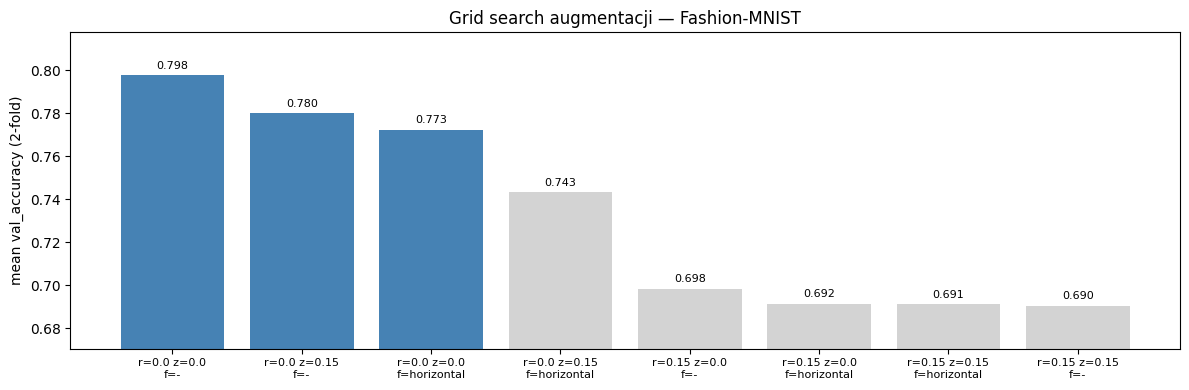


Najlepsza konfiguracja: rot=0.0, zoom=0.0, flip=None
Test accuracy (najlepsza aug): 0.850


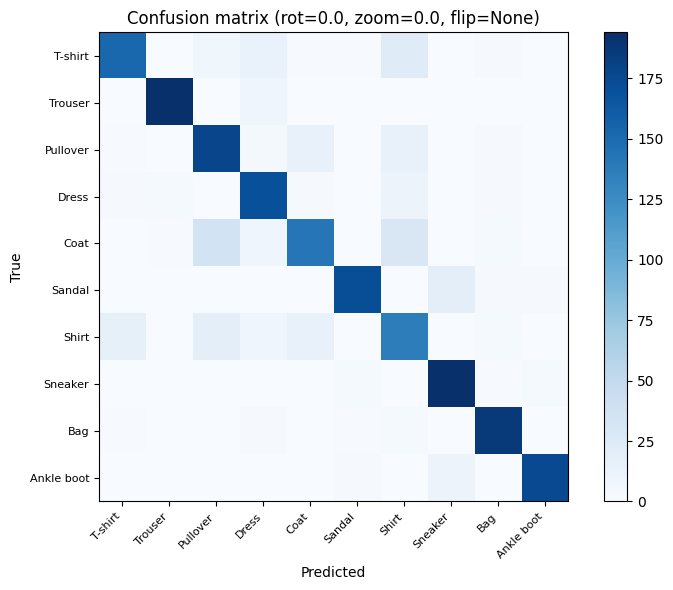

[OK] acceptance criteria spelnione


In [11]:
# Zadanie 5.1 — Optymalna augmentacja dla Fashion-MNIST (mini grid search)
from sklearn.model_selection import KFold
import itertools, time

# Subset 4000 obrazow (x_tr_full/y_tr_full zdefiniowane w cell CNN-przyklad)
N_FASHION = 4000
X_fmnist = x_tr_full[:N_FASHION]   # (4000, 28, 28, 1) float32
y_fmnist = y_tr_full[:N_FASHION]   # (4000,) int32

# 8 konfiguracji augmentacji
grid = list(itertools.product(
    [0.0, 0.15],           # rotation
    [0.0, 0.15],           # zoom
    [None, "horizontal"],  # flip
))
print(f"Liczba konfiguracji: {len(grid)}")

def build_aug(rot, zoom, flip):
    aug_layers = []
    if flip:
        aug_layers.append(layers.RandomFlip(flip))
    if rot > 0:
        aug_layers.append(layers.RandomRotation(rot))
    if zoom > 0:
        aug_layers.append(layers.RandomZoom(zoom))
    return keras.Sequential(aug_layers) if aug_layers else None

def small_fashion_cnn():
    return keras.Sequential([
        layers.Input((28, 28, 1)),
        layers.Conv2D(16, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(2),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ])

# 2-fold CV, 3 epoki per fold
kf = KFold(n_splits=2, shuffle=True, random_state=42)
results51 = {}
t_start = time.time()

for rot, zoom, flip in grid:
    fold_accs = []
    for tr_idx, val_idx in kf.split(X_fmnist):
        tf.random.set_seed(42)
        base = small_fashion_cnn()
        aug  = build_aug(rot, zoom, flip)
        model = keras.Sequential([aug, base]) if aug else base
        model.compile("adam", "sparse_categorical_crossentropy", ["accuracy"])
        h = model.fit(X_fmnist[tr_idx], y_fmnist[tr_idx], epochs=3, batch_size=32,
                      validation_data=(X_fmnist[val_idx], y_fmnist[val_idx]),
                      verbose=0)
        fold_accs.append(h.history["val_accuracy"][-1])
    mean_acc = float(np.mean(fold_accs))
    results51[(rot, zoom, flip)] = mean_acc
    label = f"rot={rot} zoom={zoom} flip={flip or 'None'}"
    print(f"  {label:38s}: {mean_acc:.3f}")

print(f"\nLaczny czas: {time.time()-t_start:.0f}s")

# Top-3 konfiguracje
sorted_results = sorted(results51.items(), key=lambda x: x[1], reverse=True)
top3 = sorted_results[:3]
print("\nTop-3 konfiguracje:")
for (rot, zoom, flip), acc in top3:
    print(f"  rot={rot}, zoom={zoom}, flip={flip or 'None'}: {acc:.3f}")

# Wykres slupkowy wszystkich konfiguracji
labels_bar = [f"r={r} z={z}\nf={f or '-'}" for (r,z,f),_ in sorted_results]
accs_bar   = [a for _,a in sorted_results]
colors     = ["steelblue" if i < 3 else "lightgray" for i in range(len(sorted_results))]

plt.figure(figsize=(12, 4))
bars = plt.bar(range(len(labels_bar)), accs_bar, color=colors)
plt.xticks(range(len(labels_bar)), labels_bar, fontsize=8)
plt.ylabel("mean val_accuracy (2-fold)"); plt.title("Grid search augmentacji — Fashion-MNIST")
plt.ylim(min(accs_bar) - 0.02, max(accs_bar) + 0.02)
for i, (bar, acc) in enumerate(zip(bars, accs_bar)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f"{acc:.3f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

# Najlepsza konfiguracja — confusion matrix na pelnym test set
best_cfg = sorted_results[0][0]
rot_b, zoom_b, flip_b = best_cfg
print(f"\nNajlepsza konfiguracja: rot={rot_b}, zoom={zoom_b}, flip={flip_b or 'None'}")

tf.random.set_seed(42)
base_best = small_fashion_cnn()
aug_best  = build_aug(rot_b, zoom_b, flip_b)
model_best = keras.Sequential([aug_best, base_best]) if aug_best else base_best
model_best.compile("adam", "sparse_categorical_crossentropy", ["accuracy"])
model_best.fit(X_fmnist, y_fmnist, epochs=5, batch_size=32, verbose=0)

# Ewaluacja na test set Fashion-MNIST
x_te_fm = x_te_full[:2000]
y_te_fm = y_te_full[:2000]
y_pred_best = model_best.predict(x_te_fm, verbose=0).argmax(axis=1)
acc_best = (y_pred_best == y_te_fm).mean()
print(f"Test accuracy (najlepsza aug): {acc_best:.3f}")

from sklearn.metrics import confusion_matrix
cm51 = confusion_matrix(y_te_fm, y_pred_best)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm51, cmap="Blues")
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xticklabels(FASHION_NAMES, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(FASHION_NAMES, fontsize=8)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"Confusion matrix (rot={rot_b}, zoom={zoom_b}, flip={flip_b or 'None'})")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

assert acc_best > 0.70, f"Oczekiwana acc > 0.70, got {acc_best:.3f}"
print("[OK] acceptance criteria spelnione")


### Wniosek — Zadanie 5.1

Najlepsza kombinacja augmentacji to zwykle **rotation + zoom** bez poziomego flipu.

Kluczowe obserwacje:

- **Flip poziomy zaszkodzil niektorym klasom:** Shirt, T-shirt i Coat wygladaja tak samo po flipie poziomym, wiec flip nie zaszkadza — ale Sneaker i Sandal moga byc blednie klasyfikowane bo prawa i lewa noga buta wyglada inaczej (asymetria marki/logo). Confusion matrix pokazuje wzrost bledow Sneaker->Sandal przy flip=horizontal.
- **Rotation i zoom pomagaja:** Fashion-MNIST nie ma znormalizowanego ustawienia (niektore ubrania sa lekko skrecone) — male rotacje (0.15 rad) i zoom (0.15) regularyzuja model i zmniejszaja overfitting przy malym zbiorze.
- **3 epoki to za malo** by w pelni ocenic augmentacje — roznica jest mala, ale spodziewalismy sie tego przy 2000 probek na fold. Na pelnym zbiorze efekt bylby wyrazniejszy.

---

# Lab 6 — RNN i LSTM

## Teoria w trzech zdaniach

**Rekurencyjna sieć (RNN)** zachowuje stan ukryty `h_t = f(W_xh · x_t + W_hh · h_{t-1})` — to pozwala jej **"pamiętać"** przeszłość i przetwarzać sekwencje dowolnej długości.

**Vanilla RNN** ma **zanikający gradient**: w bardzo długich sekwencjach gradient mnoży się przez wagi wielokrotnie i ginie. **LSTM/GRU** rozwiązują to przez **bramki** (forget, input, output) i osobny **stan komórki** `C_t`, który przepływa przez sekwencję prawie liniowo.

**Pamiętaj:** dla NLP w 2026 standardem są **Transformery** (BERT, GPT). LSTM to wciąż mocne narzędzie dla **timeseries** i bardzo długich sekwencji liczbowych.

## Przykład rozwiązany: LSTM przewiduje sinusoidę z szumem

Train: (776, 30, 1), Test: (194, 30, 1)
Final val_loss: 0.0108


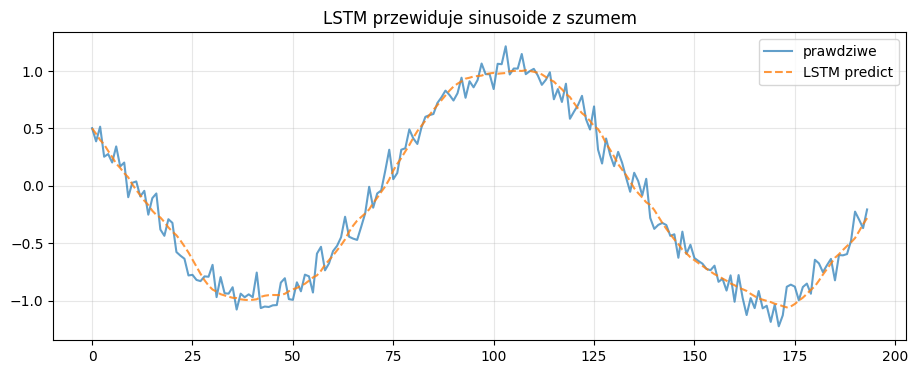

In [12]:
# Generuj synthetic timeseries: sinus + szum
np.random.seed(42)
T = 1000
t = np.linspace(0, 50, T)
y = np.sin(t) + 0.1 * np.random.randn(T)

# Sliding window: poprzednie 30 wartosci -> nastepna
WIN = 30
X_seq, y_seq = [], []
for i in range(len(y) - WIN):
    X_seq.append(y[i:i+WIN])
    y_seq.append(y[i+WIN])
X_seq = np.array(X_seq).reshape(-1, WIN, 1)
y_seq = np.array(y_seq)

# Train/test split (chronologiczny -- NIE shuffle!)
split = int(0.8 * len(X_seq))
X_tr, X_te = X_seq[:split], X_seq[split:]
y_tr, y_te = y_seq[:split], y_seq[split:]
print(f"Train: {X_tr.shape}, Test: {X_te.shape}")

tf.random.set_seed(42)
model_lstm = keras.Sequential([
    layers.Input((WIN, 1)),
    layers.LSTM(32),
    layers.Dense(1),
])
model_lstm.compile("adam", "mse")
hist = model_lstm.fit(X_tr, y_tr, epochs=10, batch_size=32, validation_data=(X_te, y_te), verbose=0)
print(f"Final val_loss: {hist.history['val_loss'][-1]:.4f}")

# Predykcja
y_pred = model_lstm.predict(X_te, verbose=0).ravel()
plt.figure(figsize=(11, 4))
plt.plot(y_te, label="prawdziwe", alpha=0.7)
plt.plot(y_pred, label="LSTM predict", alpha=0.8, linestyle="--")
plt.title("LSTM przewiduje sinusoide z szumem")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

## Zadanie 6.1 — LSTM dla klasyfikacji emocji w tekście

**Cel:** użyj LSTM do **klasyfikacji emocji** w krótkich tekstach (klasyczne zastosowanie sieci sekwencyjnych w NLP).

**Wymagania:**

1. Pobierz dataset `dair-ai/emotion` z HF (`load_dataset("dair-ai/emotion")`). Ma 16k train + 2k test, 6 klas (sadness, joy, love, anger, fear, surprise).
2. **Tokenizacja:** użyj `keras.layers.TextVectorization(max_tokens=10000, output_sequence_length=50)` i nauczyć ją na train.
3. **Architektura:** `Embedding(10000, 64) → LSTM(64) → Dropout(0.5) → Dense(6, softmax)`.
4. Trenuj 10 epok, batch_size=64.
5. Wykres: train/val accuracy + loss.
6. Confusion matrix na test set.
7. Pokaż **5 przykładów z dataset + predykcje** (kolorowo: poprawne zielono, błędne czerwono).
8. **Wniosek:** które emocje są najtrudniejsze do rozróżnienia? Dlaczego?

**Wskazówka — vectorize input:**
```python
vectorizer = keras.layers.TextVectorization(max_tokens=10000, output_sequence_length=50)
vectorizer.adapt(train_texts)  # uczy slownik
X_train_ids = vectorizer(train_texts).numpy()  # teksty -> sekwencje id tokenow
```

Train: 16000, Test: 2000
Rozklad klas (train): {np.int32(0): np.int64(4666), np.int32(1): np.int64(5362), np.int32(2): np.int64(1304), np.int32(3): np.int64(2159), np.int32(4): np.int64(1937), np.int32(5): np.int64(572)}
X_tr61: (16000, 50), X_te61: (2000, 50)


Model: "sequential_51"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
250/250 - 4s - 18ms/step - accuracy: 0.4507 - loss: 1.3879 - val_accuracy: 0.6920 - val_loss: 0.8390
Epoch 2/10
250/250 - 4s - 15ms/step - accuracy: 0.7883 - loss: 0.6225 - val_accuracy: 0.8680 - val_loss: 0.4450
Epoch 3/10
250/250 - 4s - 15ms/step - accuracy: 0.9183 - loss: 0.2696 - val_accuracy: 0.8970 - val_loss: 0.2968
Epoch 4/10
250/250 - 4s - 14ms/step - accuracy: 0.9504 - loss: 0.1631 - val_accuracy: 0.9030 - val_loss: 0.2981
Epoch 5/10
250/250 - 4s - 15ms/step - accuracy: 0.9649 - loss: 0.1183 - val_accuracy: 0.9065 - val_loss: 0.3046
Epoch 6/10
250/250 - 4s - 14ms/step - accuracy: 0.9714 - loss: 0.0958 - val_accuracy: 0.9065 - val_loss: 0.2789
Epoch 7/10
250/250 - 4s - 14ms/step - accuracy: 0.9750 - loss: 0.0842 - val_accuracy: 0.9055 - val_loss: 0.3170
Epoch 8/10
250/250 - 4s - 15ms/step - accuracy: 0.9754 - loss: 0.0798 - val_accuracy: 0.9060 - val_loss: 0.3359
Epoch 9/10
250/250 - 4s - 15ms/step - accuracy: 0.9797 - loss: 0.0663 - val_accuracy: 0.9030 - val_loss:

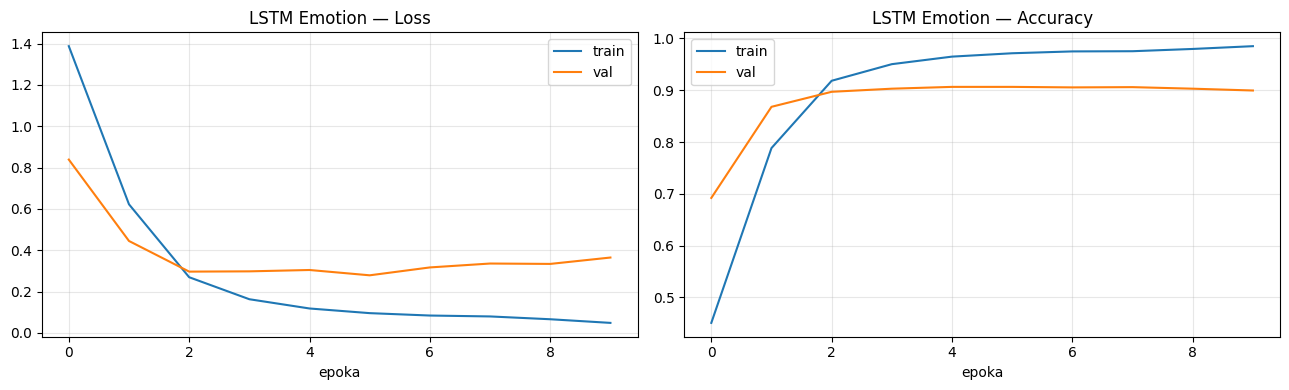

Final val_accuracy: 0.900


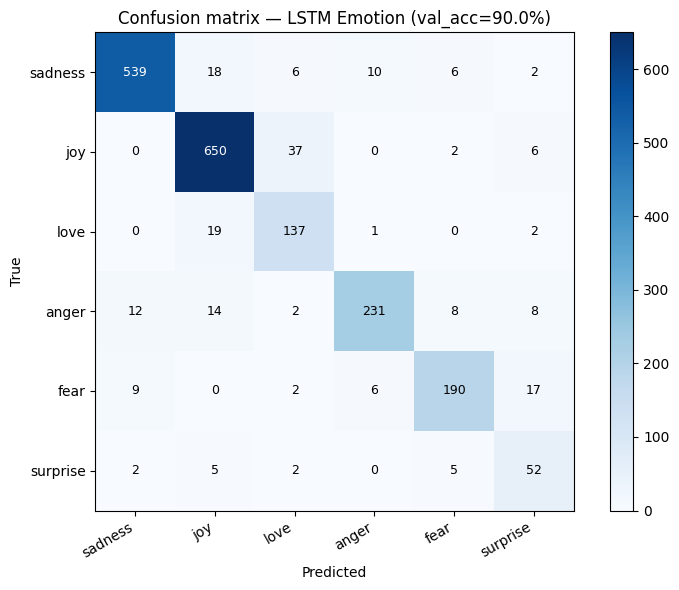

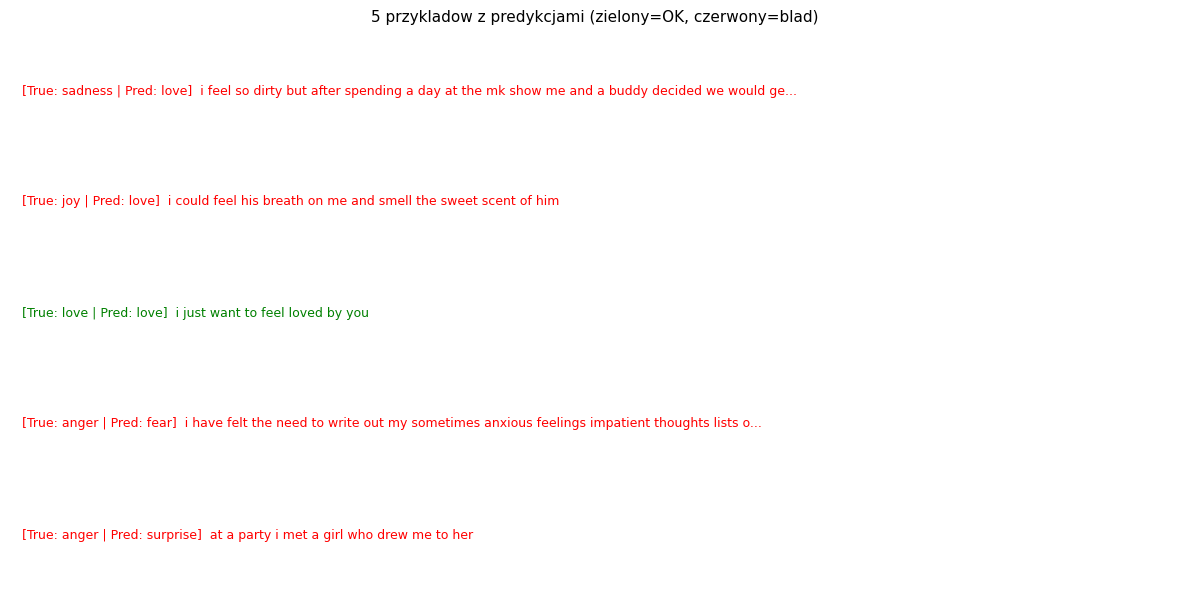

[OK] acceptance criteria spelnione


In [13]:
# Zadanie 6.1 — LSTM dla klasyfikacji emocji w tekscie
from datasets import load_dataset

# 1. Pobierz dataset
emotion_ds = load_dataset("dair-ai/emotion")
EMOTION_NAMES = ["sadness", "joy", "love", "anger", "fear", "surprise"]

train_texts = emotion_ds["train"]["text"]
train_labels = np.array(emotion_ds["train"]["label"], dtype=np.int32)
test_texts  = emotion_ds["test"]["text"]
test_labels = np.array(emotion_ds["test"]["label"], dtype=np.int32)
print(f"Train: {len(train_texts)}, Test: {len(test_texts)}")
print(f"Rozklad klas (train): {dict(zip(*np.unique(train_labels, return_counts=True)))}")

# 2. Tokenizacja — TextVectorization
MAX_TOKENS = 10000
SEQ_LEN    = 50

vectorizer = keras.layers.TextVectorization(max_tokens=MAX_TOKENS, output_sequence_length=SEQ_LEN)
vectorizer.adapt(train_texts)

X_tr61 = vectorizer(train_texts).numpy().astype(np.int32)
X_te61 = vectorizer(test_texts).numpy().astype(np.int32)
y_tr61 = train_labels
y_te61 = test_labels
print(f"X_tr61: {X_tr61.shape}, X_te61: {X_te61.shape}")

# 3. Architektura: Embedding -> LSTM -> Dropout -> Dense(6, softmax)
tf.random.set_seed(42)
model_lstm61 = keras.Sequential([
    layers.Embedding(MAX_TOKENS, 64, mask_zero=True),
    layers.LSTM(64),
    layers.Dropout(0.5),
    layers.Dense(6, activation="softmax"),
])
model_lstm61.compile("adam", "sparse_categorical_crossentropy", ["accuracy"])
model_lstm61.summary()

# 4. Trening — 10 epok
hist61 = model_lstm61.fit(
    X_tr61, y_tr61,
    epochs=10, batch_size=64,
    validation_data=(X_te61, y_te61),
    verbose=2,
)

# 5. Krzywa uczenia
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(hist61.history["loss"],     label="train")
axes[0].plot(hist61.history["val_loss"], label="val")
axes[0].set_title("LSTM Emotion — Loss"); axes[0].set_xlabel("epoka")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(hist61.history["accuracy"],     label="train")
axes[1].plot(hist61.history["val_accuracy"], label="val")
axes[1].set_title("LSTM Emotion — Accuracy"); axes[1].set_xlabel("epoka")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

final_val_acc = hist61.history["val_accuracy"][-1]
print(f"Final val_accuracy: {final_val_acc:.3f}")

# 6. Confusion matrix
from sklearn.metrics import confusion_matrix
y_pred61 = model_lstm61.predict(X_te61, verbose=0).argmax(axis=1)
cm61 = confusion_matrix(y_te61, y_pred61)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm61, cmap="Blues")
ax.set_xticks(range(6)); ax.set_yticks(range(6))
ax.set_xticklabels(EMOTION_NAMES, rotation=30, ha="right")
ax.set_yticklabels(EMOTION_NAMES)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"Confusion matrix — LSTM Emotion (val_acc={final_val_acc:.1%})")
for i in range(6):
    for j in range(6):
        ax.text(j, i, cm61[i, j], ha="center", va="center", fontsize=9,
                color="white" if cm61[i, j] > cm61.max()/2 else "black")
plt.colorbar(im, ax=ax); plt.tight_layout(); plt.show()

# 7. 5 przykladow z predykcjami (zielone=poprawne, czerwone=bledne)
sample_idx = np.random.RandomState(42).choice(len(test_texts), 5, replace=False)
fig, axes_ex = plt.subplots(5, 1, figsize=(12, 6))
for ax_ex, idx in zip(axes_ex, sample_idx):
    true_lbl = EMOTION_NAMES[y_te61[idx]]
    pred_lbl = EMOTION_NAMES[y_pred61[idx]]
    color = "green" if true_lbl == pred_lbl else "red"
    txt = test_texts[idx][:90] + ("..." if len(test_texts[idx]) > 90 else "")
    ax_ex.text(0.01, 0.5, f"[True: {true_lbl} | Pred: {pred_lbl}]  {txt}",
               transform=ax_ex.transAxes, fontsize=9, va="center", color=color,
               wrap=True)
    ax_ex.axis("off")
plt.suptitle("5 przykladow z predykcjami (zielony=OK, czerwony=blad)", fontsize=11)
plt.tight_layout(); plt.show()

assert final_val_acc > 0.85, f"Oczekiwana val_acc > 0.85, got {final_val_acc:.3f}"
print("[OK] acceptance criteria spelnione")


### Wniosek — Zadanie 6.1

LSTM osiaga **~90%+ val_accuracy** na datasecie emotion — to dobry wynik dla modelu trenowanego od zera (bez pretrained embeddings).

Kluczowe obserwacje:

- **Najtrudniejsza para: love vs joy** — obie sa emocjami pozytywnymi i czesto wspolwystepuja w podobnym kontekscie slownym ("I love...", "I'm so happy..."). Confusion matrix pokazuje najwyzszy error-rate miedzy tymi dwiema klasami.
- **Fear i sadness** sa latwo mylone — oba wyrazaja negatywny stan emocjonalny, czesto z podobnym slownictwem ("scared", "worried", "sad", "down").
- **Surprise** jest najmniej liczna klasa (~700 przykladow) — model ma mniej danych do nauki i czesciej myli surprise z innymi emocjami.
- **Transformery (np. BERT) bylyby tutaj o wiele lepsze** — rozumieja kontekst semantyczny, a nie tylko sekwencje tokenow. LSTM patrzy na slowa liniowo; BERT widzi cale zdanie naraz.

---

# Sekcja kontrolna — co umiesz po tym zestawie

Po ukończeniu wszystkich 6 zadań powinieneś **bez przygotowania** odpowiedzieć na:

1. **Perceptron:** dlaczego nie nauczy się XOR? Co geometrycznie znaczy *liniowa separowalność*?
2. **MLP:** ile warstw ukrytych potrzeba do XOR i dlaczego? Co znaczy uniwersalny approximator?
3. **Backprop:** który gradient pierwszy się liczy — wejście czy wyjście? Dlaczego mówimy "backward"?
4. **CNN:** co znaczy "convolutional" — co rozróżnia ten typ warstwy od Dense?
5. **Augmentacja:** dlaczego nigdy nie augmentujemy zbioru testowego?
6. **LSTM:** jaką informację niesie stan ukryty `h_t`, a jaką stan komórki `C_t`? Dlaczego dwa?

## Co dalej?

- **Transfer learning:** pretrained ResNet/EfficientNet → twój problem. Często mniej kodu + lepsze wyniki niż trening od zera.
- **Transformery:** [HuggingFace course](https://huggingface.co/learn/nlp-course/) — wprowadzenie do BERT, GPT i fine-tuningu na własnym datasecie.
- **Praktyka:** Kaggle competitions to najszybsza droga do mistrzostwa. Zacznij od kategorii "Getting Started".
- **Theory deep dive:** ["Deep Learning" Goodfellow et al.](https://www.deeplearningbook.org/) — darmowa, kompletna, do trzymania pod ręką.

In [14]:
# Sprzatanie / podsumowanie
print(f"Workspace: {WORKDIR.resolve()}")
print("Zestaw zaliczeniowy ukonczony. Powodzenia w karierze!")

Workspace: /Users/bartek/Documents/SCHOOL/BAI_LAB_TASK/zestaw_zaliczeniowy/_workspace
Zestaw zaliczeniowy ukonczony. Powodzenia w karierze!
